# IS 5540 Project - Data Wrangling, Modeling, and Model Performance

In [1]:
# LOAD PACKAGES
load_or_install <- function(pkgs) {
  for(p in pkgs) {
    if(!requireNamespace(p, quietly = TRUE)) {
      message(paste('Installing package:', p))
      install.packages(p)
    }
    library(p, character.only = TRUE)
  }
}

# load in tidyverse for data manip and plotting
# lubridate for handling date values
# scales for formatting for our plots
load_or_install(c('tidyverse', 'lubridate', 'scales', 'broom', 'forcats'))

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors

Attaching package: ‘scales’

The following object is masked from ‘package:purrr’:

    discard

The following object is masked from ‘package:readr’:

    col_factor



Warning messages:
1: package ‘tidyverse’ was built under R version 4.5.3 
2: package ‘ggplot2’ was built under R version 4.5.3 
3: package ‘readr’ was built under R version 4.5.3 
4: package ‘purrr’ was built under R version 4.5.3 
5: package ‘dplyr’ was built under R version 4.5.3 
6: package ‘stringr’ was built under R version 4.5.3 


In [2]:
# LOAD CSV FILE
music <- read.csv("C:\\Users\\coolg\\OneDrive - Harding University\\Courses\\Spring 2026\\IS 5540\\spotify-tracks-dataset.csv") # load csv data

In [3]:
sum(is.na(music))
# Surprisingly no NA values!
# This is nice for data analysis
# If there were NAs, I most likely would have done mean imputation for normal data
# If it was not normal, I would have dropped them completely

[1] 0

## Data Wrangling and Manipulation

In [4]:
# Quick view of count by genre
# Each 114 genres has 1000 records
music %>% count(track_genre)

          track_genre    n
1            acoustic 1000
2            afrobeat 1000
3            alt-rock 1000
4         alternative 1000
5             ambient 1000
6               anime 1000
7         black-metal 1000
8           bluegrass 1000
9               blues 1000
10             brazil 1000
11          breakbeat 1000
12            british 1000
13           cantopop 1000
14      chicago-house 1000
15           children 1000
16              chill 1000
17          classical 1000
18               club 1000
19             comedy 1000
20            country 1000
21              dance 1000
22          dancehall 1000
23        death-metal 1000
24         deep-house 1000
25     detroit-techno 1000
26              disco 1000
27             disney 1000
28      drum-and-bass 1000
29                dub 1000
30            dubstep 1000
31                edm 1000
32            electro 1000
33         electronic 1000
34                emo 1000
35               folk 1000
36              forro 1000
3

In [5]:
# Adding column to change duration from ms to seconds, and standardize loudness
# Then, filter only unique songs, keeping all the rows
# Then, filter to specific genres (the most popular ones)
# Lastly, select certain columns for data analysis
music_small <- music %>%
  mutate(
    duration_sec = round(duration_ms / 1000, 0),
    loudness = (loudness - mean(loudness)) / sd(loudness)
  ) %>%
  distinct(track_name, .keep_all = TRUE) %>%
  filter(track_genre %in% c("pop", "rock", "hip-hop", "country", "classical", "jazz")) %>%
  select(tempo, mode, popularity, duration_sec, track_genre, track_name, energy, loudness, acousticness)

## Detect Outliers

In [6]:
# Function to detect outliers using IQR method
# Returns T/F for each value
# 1.5 * IQR
flag_outliers_iqr <- function(x) {
  q1 = quantile(x, 0.25, na.rm = TRUE)
  q3 = quantile(x, 0.75, na.rm = TRUE)
  iqr = q3 - q1

  # upper & lower
  lower <- q1 - 1.5 * iqr
  upper <- q3 + 1.5 * iqr

  # flag values outside "fences"
  x < lower | x > upper
}

In [7]:
music_small <- music_small %>%
  mutate(
    tempo_outlier = flag_outliers_iqr(tempo),
    mode_outlier = flag_outliers_iqr(mode),
    popularity_outlier = flag_outliers_iqr(popularity),
    duration_sec_outlier = flag_outliers_iqr(duration_sec),
    energy_outlier = flag_outliers_iqr(energy),
    loudness_outlier = flag_outliers_iqr(loudness),
    acousticness_outlier = flag_outliers_iqr(acousticness)
  )

# Count how many rows flagged for the four numeric data
music_small %>% count(tempo_outlier) %>% print()
music_small %>% count(mode_outlier) %>% print()
music_small %>% count(popularity_outlier) %>% print()
music_small %>% count(duration_sec_outlier) %>% print()
music_small %>% count(energy_outlier) %>% print()
music_small %>% count(loudness_outlier) %>% print()
music_small %>% count(acousticness_outlier) %>% print()

  tempo_outlier    n
1         FALSE 2374
2          TRUE    2
  mode_outlier    n
1        FALSE 2376
  popularity_outlier    n
1              FALSE 2376
  duration_sec_outlier    n
1                FALSE 2204
2                 TRUE  172
  energy_outlier    n
1          FALSE 2376
  loudness_outlier    n
1            FALSE 2305
2             TRUE   71
  acousticness_outlier    n
1                FALSE 2376


In [8]:
# Filter to outliers for duration, keep a few columns, and inspect extremes
music_small %>%
  filter(duration_sec_outlier) %>%
  arrange(desc(duration_sec)) %>%
  slice_head(n = 10)

     tempo mode popularity duration_sec track_genre                                                            track_name energy    loudness acousticness
1  103.624    1         33         2647   classical                              Chanting of the Gayatri Mantra 108 Times 0.2740 -1.17809565        0.950
2  148.153    1         32         2545   classical                             Ram Ram Jai Raja Ram Ram Ram Jai Sita Ram 0.6380  0.04671796        0.695
3  101.052    1         39         1799   classical                                         Vishnu Sahasranamam - Dhyanam 0.2640 -0.30462062        0.899
4   89.848    1         43         1755   classical                                         Lalitha Sahasranama Sthothram 0.4380 -0.02983289        0.815
5   72.341    1          0         1452   classical Trio élégiaque No. 2 in D Minor, Op. 9: II. Quasi variazione. Andante 0.0329 -3.58099704        0.968
6   78.113    0          0         1372   classical  Trio élégiaque No. 2 in

In [9]:
# View count of outliers by genre
music_small %>%
  group_by(track_genre) %>%
  mutate(
    duration_outlier_within_genre = flag_outliers_iqr(duration_sec)
  ) %>%
  ungroup() %>%
  count(track_genre, duration_outlier_within_genre)

# A tibble: 12 × 3
   track_genre duration_outlier_within_genre     n
   <chr>       <lgl>                         <int>
 1 classical   FALSE                           716
 2 classical   TRUE                             29
 3 country     FALSE                           497
 4 country     TRUE                             10
 5 hip-hop     FALSE                           576
 6 hip-hop     TRUE                             31
 7 jazz        FALSE                           160
 8 jazz        TRUE                              6
 9 pop         FALSE                           219
10 pop         TRUE                             16
11 rock        FALSE                           108
12 rock        TRUE                              8

In [10]:
# Filter out extreme duration values
# 3 * IQR
# Also filter out popularity <= 25 (I don't care about terrible songs)

music_small <- music_small %>%
  filter(
    duration_sec >= quantile(duration_sec, 0.25) - 3 * IQR(duration_sec) &
    duration_sec <= quantile(duration_sec, 0.75) + 3 * IQR(duration_sec) &
    popularity > 25
  )

## Model the Data

In [11]:
# Select only numeric columns
music_small_num <- music_small %>%
  select(where(is.numeric))

In [12]:
# Correlation Matrix of Numeric Values
cor(music_small_num)

                   tempo        mode  popularity duration_sec     energy    loudness acousticness
tempo         1.00000000 -0.02679556  0.03205205  -0.01581276  0.1160685  0.08262912  -0.13665294
mode         -0.02679556  1.00000000 -0.15582183   0.06013728 -0.1376011 -0.12201065   0.11300523
popularity    0.03205205 -0.15582183  1.00000000  -0.10702086  0.2214485  0.24327900  -0.39663192
duration_sec -0.01581276  0.06013728 -0.10702086   1.00000000 -0.0148455 -0.06243738   0.09824911
energy        0.11606851 -0.13760113  0.22144845  -0.01484550  1.0000000  0.79329896  -0.70397413
loudness      0.08262912 -0.12201065  0.24327900  -0.06243738  0.7932990  1.00000000  -0.59850139
acousticness -0.13665294  0.11300523 -0.39663192   0.09824911 -0.7039741 -0.59850139   1.00000000

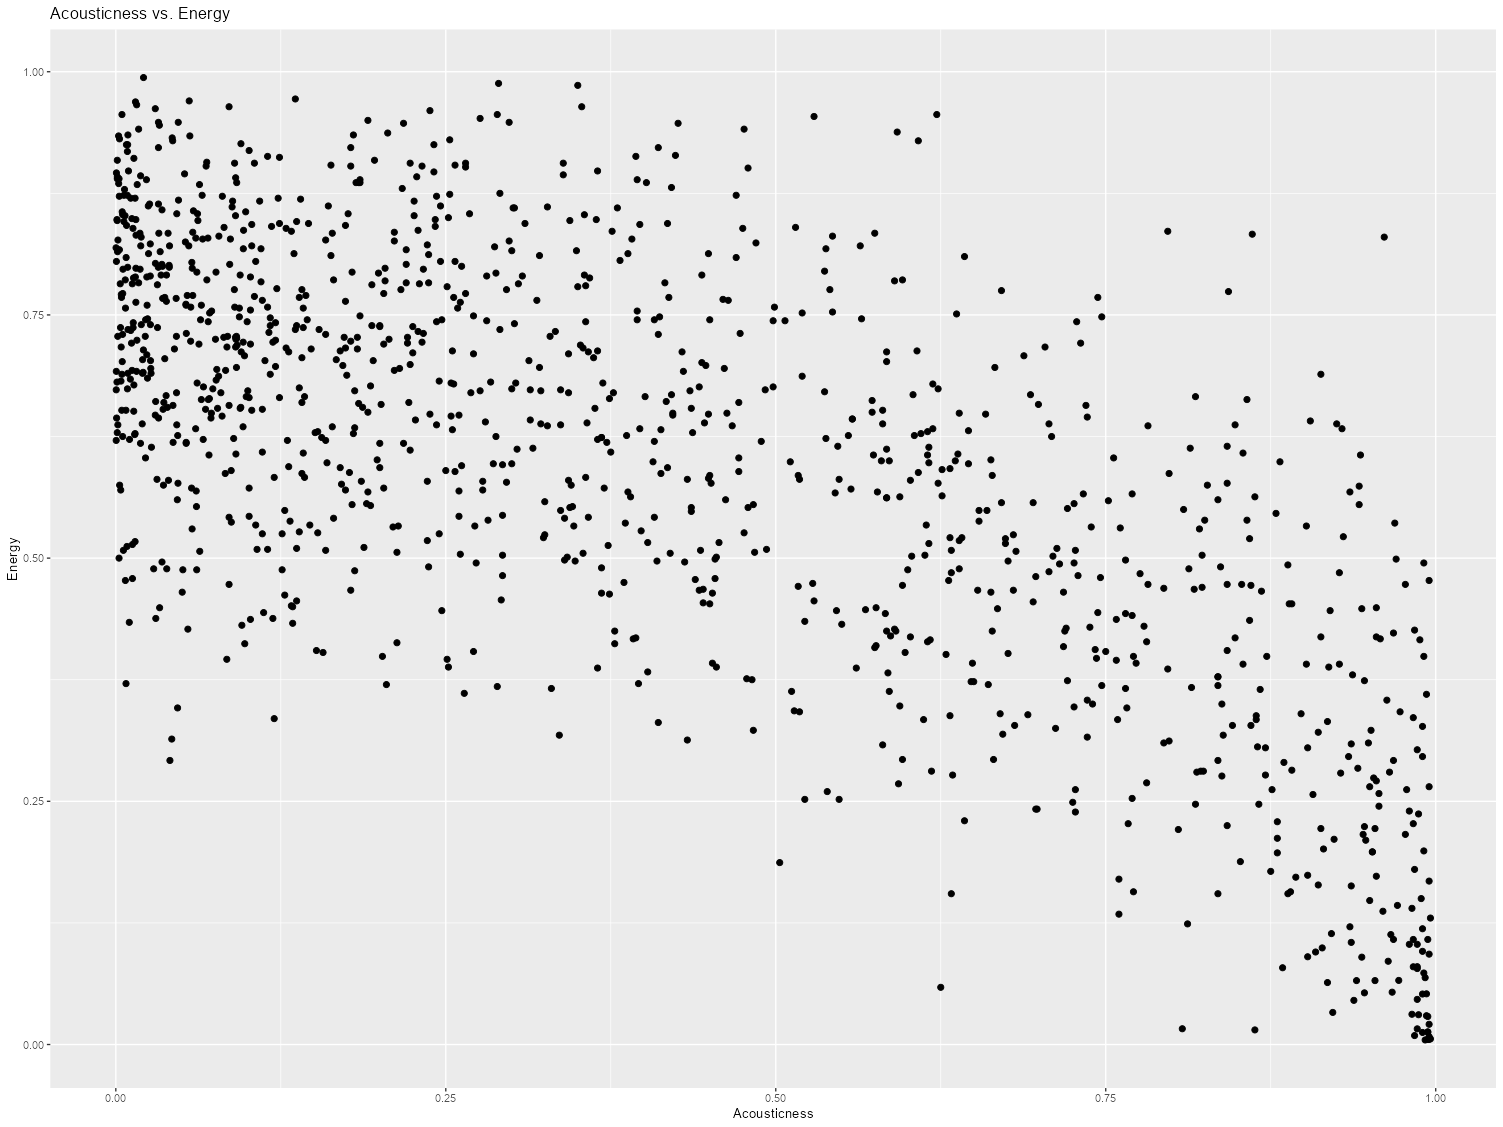

In [13]:
# Scatterplot acousticness & energy
ggplot(music_small, aes(x = acousticness, y = energy)) +
  geom_point(size = 2) +
  labs(
    title = 'Acousticness vs. Energy',
    x = 'Acousticness',
    y = 'Energy'
  )

In [14]:
# Fit a linear regression
# Predict energy from acousticness
music_model_acoustic <- lm(energy ~ acousticness, data = music_small)

music_model_acoustic


Call:
lm(formula = energy ~ acousticness, data = music_small)

Coefficients:
 (Intercept)  acousticness  
      0.7870       -0.4848  


In [15]:
# Fit a linear regression
# Predict energy from loudness
music_model_loudness <- lm(energy ~ loudness, data = music_small)

music_model_loudness


Call:
lm(formula = energy ~ loudness, data = music_small)

Coefficients:
(Intercept)     loudness  
     0.5910       0.1776  


In [16]:
# Fit a linear regression
# Predict energy from acousticness AND loudness
music_model_multiple <- lm(energy ~ acousticness + loudness, data = music_small)

music_model_multiple


Call:
lm(formula = energy ~ acousticness + loudness, data = music_small)

Coefficients:
 (Intercept)  acousticness      loudness  
      0.6897       -0.2459        0.1298  


In [17]:
# Fit a linear regression
# Predict energy from acousticness AND loudness INTERACTION
music_model_interaction <- lm(energy ~ acousticness * loudness, data = music_small)

music_model_interaction


Call:
lm(formula = energy ~ acousticness * loudness, data = music_small)

Coefficients:
          (Intercept)           acousticness               loudness  acousticness:loudness  
               0.6579                -0.2228                 0.2190                -0.1145  


In [18]:
summary(music_model_acoustic)


Call:
lm(formula = energy ~ acousticness, data = music_small)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.47508 -0.10471  0.00566  0.10598  0.50892 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.786958   0.007173  109.72   <2e-16 ***
acousticness -0.484787   0.014031  -34.55   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1574 on 1215 degrees of freedom
Multiple R-squared:  0.4956,	Adjusted R-squared:  0.4952 
F-statistic:  1194 on 1 and 1215 DF,  p-value: < 2.2e-16


In [19]:
summary(music_model_loudness)


Call:
lm(formula = energy ~ loudness, data = music_small)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.44858 -0.09250  0.00509  0.09943  0.43854 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.591048   0.003868  152.80   <2e-16 ***
loudness    0.177611   0.003911   45.42   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1349 on 1215 degrees of freedom
Multiple R-squared:  0.6293,	Adjusted R-squared:  0.629 
F-statistic:  2063 on 1 and 1215 DF,  p-value: < 2.2e-16


In [20]:
summary(music_model_multiple)


Call:
lm(formula = energy ~ acousticness + loudness, data = music_small)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.33026 -0.08385  0.00140  0.08233  0.44283 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.689650   0.006319  109.14   <2e-16 ***
acousticness -0.245913   0.013259  -18.55   <2e-16 ***
loudness      0.129761   0.004311   30.10   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1191 on 1214 degrees of freedom
Multiple R-squared:  0.7112,	Adjusted R-squared:  0.7107 
F-statistic:  1495 on 2 and 1214 DF,  p-value: < 2.2e-16


In [21]:
summary(music_model_interaction)


Call:
lm(formula = energy ~ acousticness * loudness, data = music_small)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.36158 -0.08174 -0.00002  0.07402  0.44179 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)            0.657863   0.006956  94.579   <2e-16 ***
acousticness          -0.222757   0.013026 -17.100   <2e-16 ***
loudness               0.219018   0.010272  21.323   <2e-16 ***
acousticness:loudness -0.114453   0.012042  -9.504   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.115 on 1213 degrees of freedom
Multiple R-squared:  0.7312,	Adjusted R-squared:  0.7305 
F-statistic:  1100 on 3 and 1213 DF,  p-value: < 2.2e-16


In [22]:
glance(music_model_acoustic)

# A tibble: 1 × 12
  r.squared adj.r.squared sigma statistic   p.value    df logLik    AIC    BIC deviance df.residual  nobs
      <dbl>         <dbl> <dbl>     <dbl>     <dbl> <dbl>  <dbl>  <dbl>  <dbl>    <dbl>       <int> <int>
1     0.496         0.495 0.157     1194. 9.08e-183     1   524. -1043. -1028.     30.1        1215  1217

In [23]:
glance(music_model_loudness)

# A tibble: 1 × 12
  r.squared adj.r.squared sigma statistic   p.value    df logLik    AIC    BIC deviance df.residual  nobs
      <dbl>         <dbl> <dbl>     <dbl>     <dbl> <dbl>  <dbl>  <dbl>  <dbl>    <dbl>       <int> <int>
1     0.629         0.629 0.135     2063. 4.21e-264     1   712. -1418. -1402.     22.1        1215  1217

In [24]:
glance(music_model_multiple)

# A tibble: 1 × 12
  r.squared adj.r.squared sigma statistic p.value    df logLik    AIC    BIC deviance df.residual  nobs
      <dbl>         <dbl> <dbl>     <dbl>   <dbl> <dbl>  <dbl>  <dbl>  <dbl>    <dbl>       <int> <int>
1     0.711         0.711 0.119     1495.       0     2   864. -1719. -1699.     17.2        1214  1217

In [25]:
glance(music_model_interaction)

# A tibble: 1 × 12
  r.squared adj.r.squared sigma statistic p.value    df logLik    AIC    BIC deviance df.residual  nobs
      <dbl>         <dbl> <dbl>     <dbl>   <dbl> <dbl>  <dbl>  <dbl>  <dbl>    <dbl>       <int> <int>
1     0.731         0.731 0.115     1100.       0     3   907. -1805. -1779.     16.0        1213  1217

## Run Diagnostics

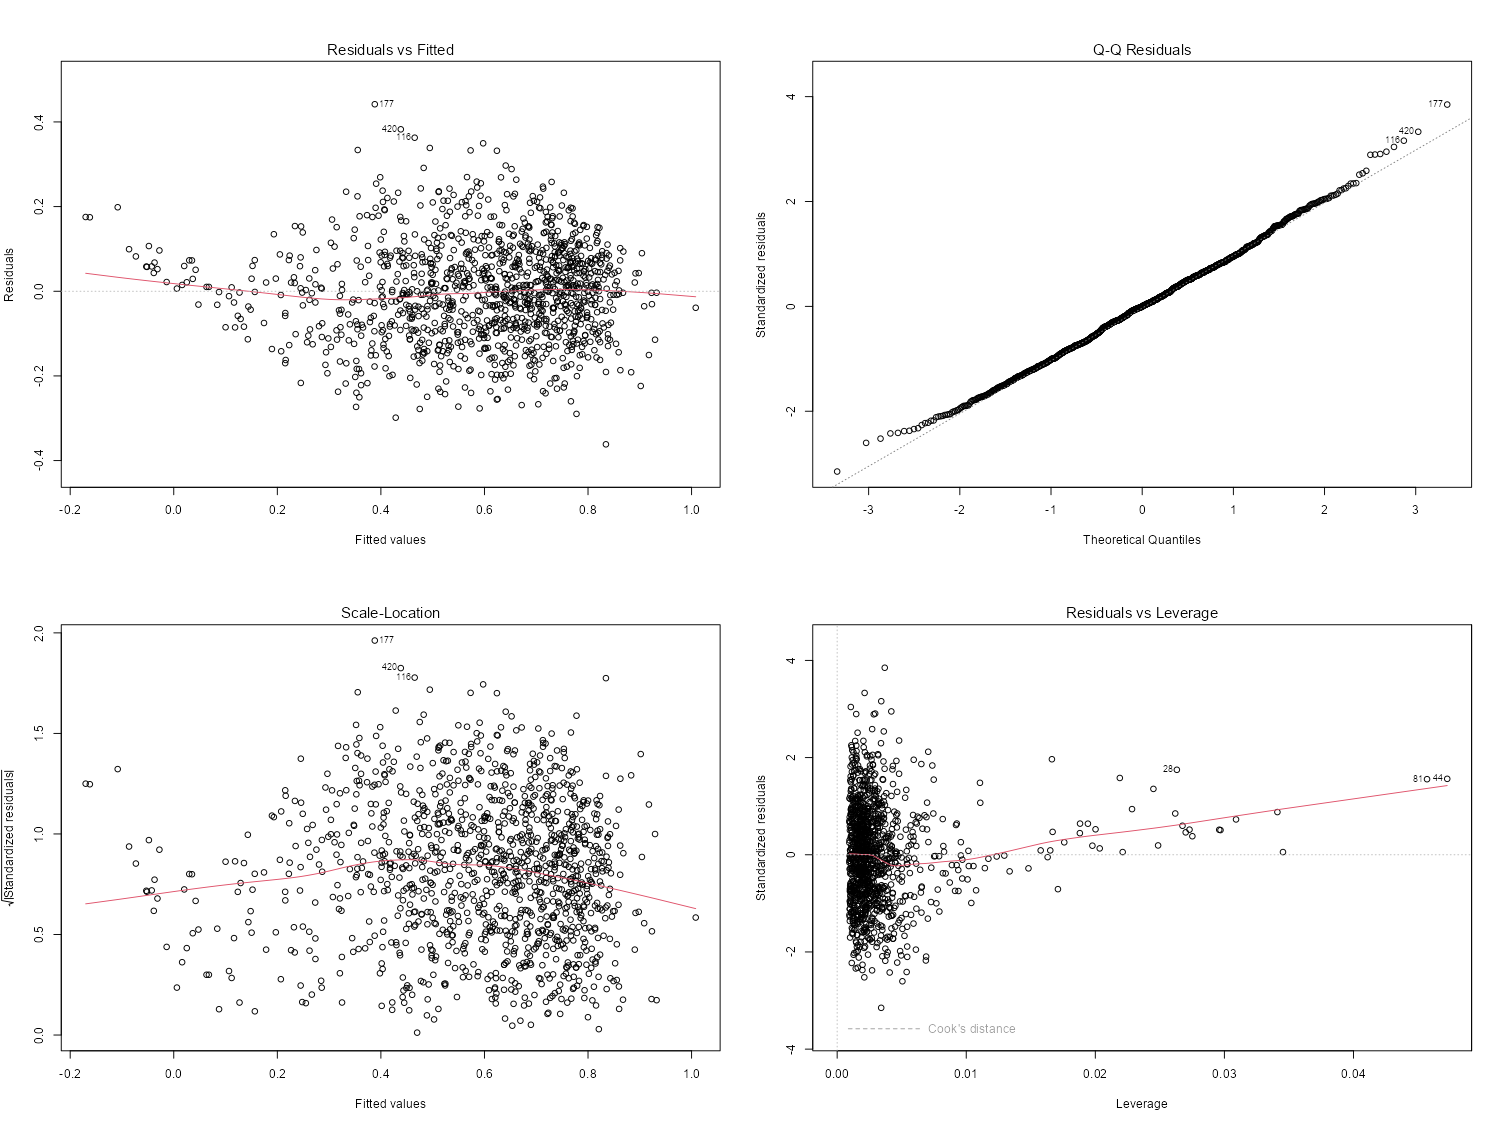

In [26]:
# The 2 x 2 matrix of diagnostics
par(mfrow = c(2, 2))
plot(music_model_interaction)
par(mfrow = c(1, 1))

In [27]:
std_res <- rstandard(music_model_interaction)

labeled_ids <- order(abs(std_res), decreasing = TRUE)[1:3]

labeled_ids

[1] 177 420 116

In [28]:
music_small[labeled_ids, ]

      tempo mode popularity duration_sec track_genre              track_name energy   loudness acousticness tempo_outlier mode_outlier popularity_outlier
177 171.774    1         29          259   classical Aanai Mugathaan Revival  0.830 -0.5098167        0.961         FALSE        FALSE              FALSE
420 169.131    1         41          207     country         Queen Of Hearts  0.821 -0.6070462        0.564         FALSE        FALSE              FALSE
116 128.030    1         34          141   classical            Sargam Surge  0.828 -0.6054555        0.391         FALSE        FALSE              FALSE
    duration_sec_outlier energy_outlier loudness_outlier acousticness_outlier
177                FALSE          FALSE            FALSE                FALSE
420                FALSE          FALSE            FALSE                FALSE
116                FALSE          FALSE            FALSE                FALSE

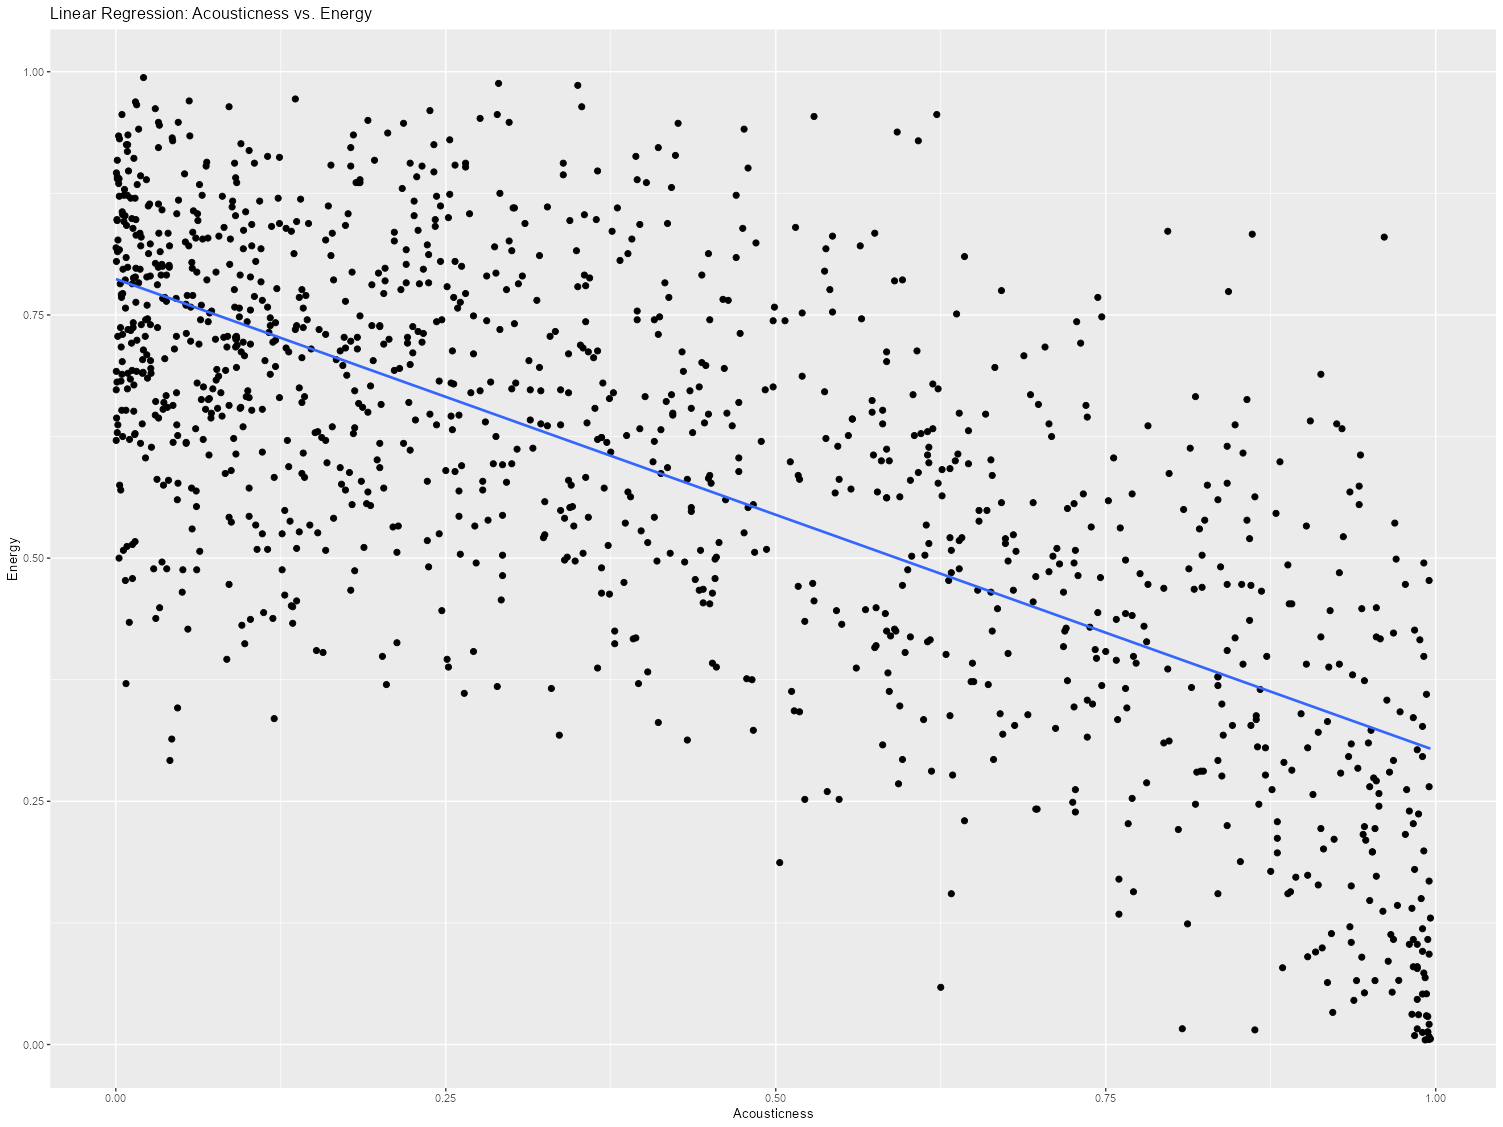

In [29]:
# Acoustic vs. Energy scatterplot with linear model overlay
ggplot(music_small, aes(x = acousticness, y = energy)) +
  geom_point(size = 2) +
  geom_smooth(
    method = 'lm',
    se = FALSE,
    formula = 'y ~ x'
  ) +
    labs(
      title = 'Linear Regression: Acousticness vs. Energy',
      x = 'Acousticness',
      y = 'Energy',
    )

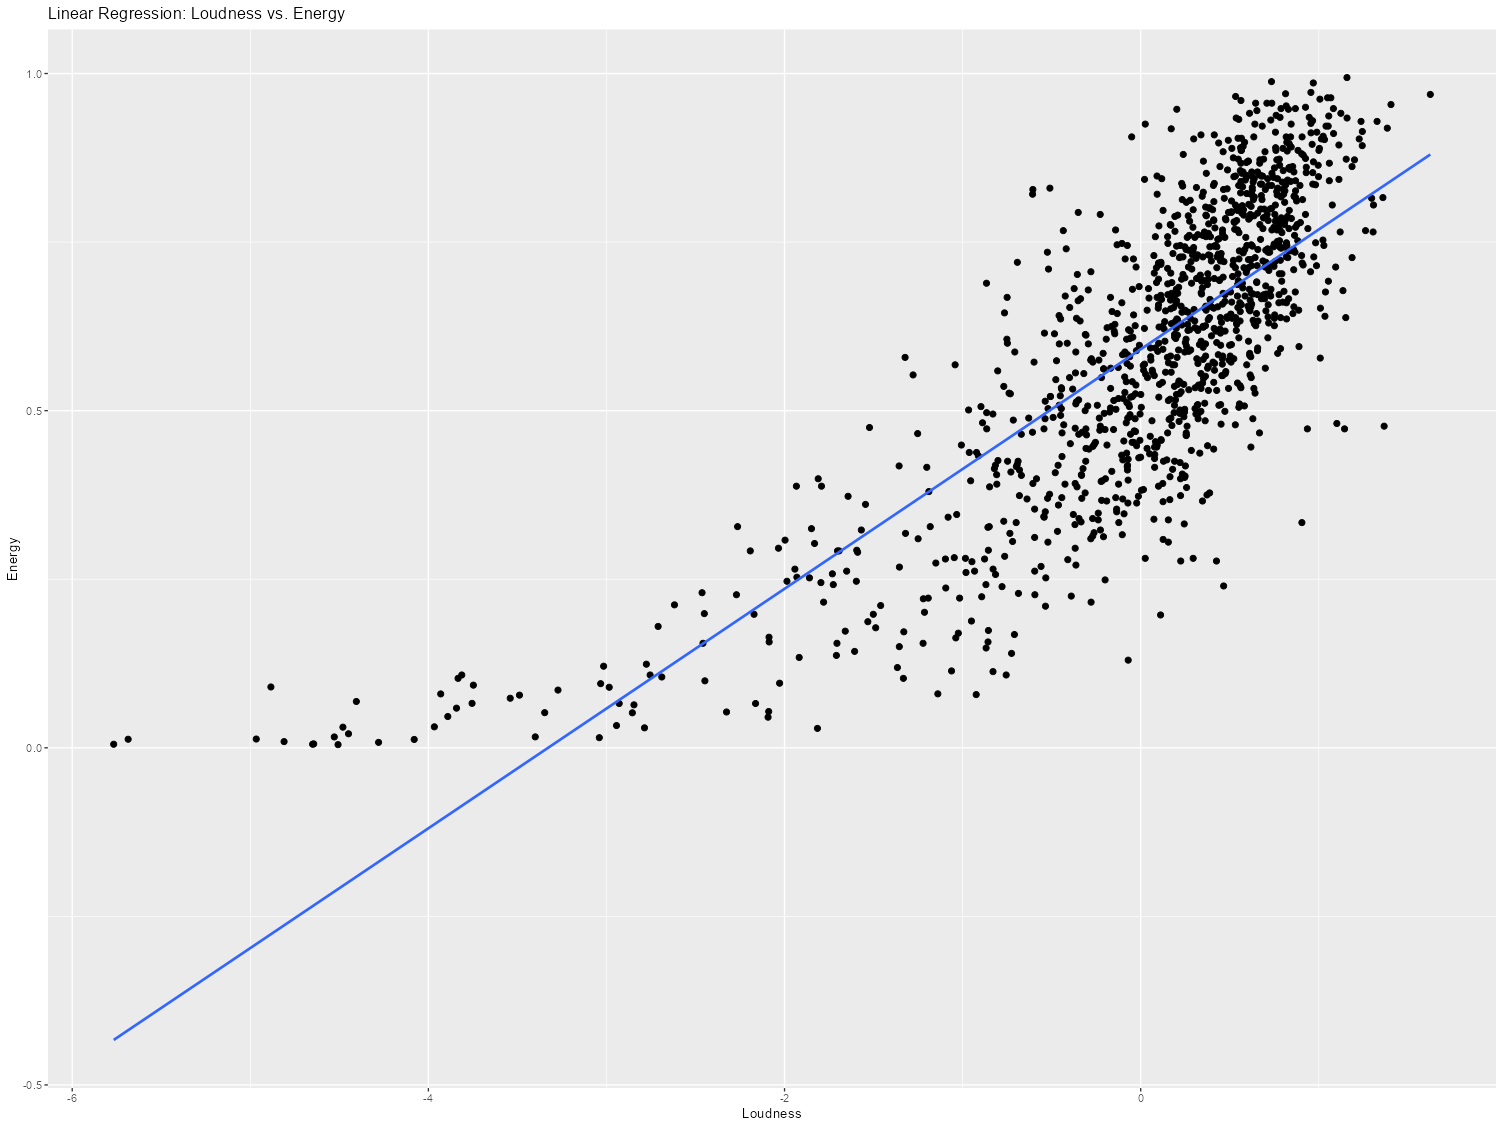

In [30]:
# Loudness vs. Energy scatterplot with linear model overlay
ggplot(music_small, aes(x = loudness, y = energy)) +
  geom_point(size = 2) +
  geom_smooth(
    method = 'lm',
    se = FALSE,
    formula = 'y ~ x'
  ) +
    labs(
      title = 'Linear Regression: Loudness vs. Energy',
      x = 'Loudness',
      y = 'Energy'
    )